### Libraries and install

In [1]:
!pip install scikit-learn==1.0.2 -q

!pip install pycaret -q
!pip install ydata-profiling -q
!pip install unidecode -q
!pip install umap-learn -q
!pip install pycaret[analysis] -q

import logging
import pandas as pd
from unidecode import unidecode
from ydata_profiling import ProfileReport
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from pycaret.anomaly import *
from pyod.models.gmm import GMM
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.iforest import IForest
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score
from joblib import load, dump
from tqdm import tqdm
from pycaret.anomaly import *
import umap
import logging
from pyod.models.mad import MAD
from pycaret.classification import get_config


2024-09-10 14:51:19.752933: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-10 14:51:20.042422: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-10 14:51:21.238348: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2024-09-10 14:51:21.238468: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinf

### Configs and data initialization

In [2]:
import logging

logging.basicConfig(
                    filename='logfile.txt',
                    filemode='a',
                    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
                    level=logging.INFO,
                    force=True, # Resets any previous configuration
                    )

# Create a custom logger
logger = logging.getLogger(__name__)
# Create handlers
c_handler = logging.StreamHandler()
c_handler.setLevel(logging.INFO)
f_handler = logging.FileHandler('logfile.txt', mode='w')
f_handler.setLevel(logging.INFO)

# Create formatters and add it to handlers
c_format = logging.Formatter('%(name)s - %(levelname)s - %(message)s')
f_format = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
c_handler.setFormatter(c_format)
f_handler.setFormatter(f_format)

# Add handlers to the logger
logger.addHandler(c_handler)
logger.addHandler(f_handler)




# FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR, 	COMBUSTÍVEIS E LUBRIFICANTES., LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES, TELEFONIA, Emissão bilhete aéreo ( PASSAGEM AÉREA - SIGEPA,  PASSAGEM AÉREA - RPA)
CATEGORY = 'COMBUSTÍVEIS E LUBRIFICANTES.'
DIRECTORY = f'results-sbbd/models/{unidecode(CATEGORY.replace(" ", "_"))}/'
#MODELS = ['knn', 'lof', 'iforest']
#mad = MAD()

MODELS = ['iforest']

### Models to tune
gmm_model = GMM()
auto_model = AutoEncoder()
iforest_model = IForest(behaviour='new', bootstrap=False, contamination='auto',
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=-1,
    random_state=123, verbose=0)

df = pd.read_csv('/home/jovyan/notebook-antigo/schiavon/congress_person/data/Ano-2019-2023.csv', index_col=0)
df = df[df.txtDescricao == CATEGORY]

print(f'Tamanho dataset antes {len(df)}')
df_shrink = df[df['vlrLiquido'] >= 0]
print(f'Foram removidas {len(df) - len(df_shrink)} linhas com valores negativos')
print(f'Tamanho dataset depois {len(df_shrink)}')

### Calculate mean value to include in dataset
mean_values = df_shrink.groupby('txtFornecedor')['field_value_ajustmented'].mean()
df_shrink['mean_value'] =df_shrink['txtFornecedor'].map(mean_values)

# List of ignored and included features
ignored_features = ['nuDeputadoId', 'txNomeParlamentar']
models_features = ['txtFornecedor', 'field_value_ajustmented', 'sgPartido', 'mean_value', 'nuDeputadoId', 'txNomeParlamentar', 'datEmissao']

df_shrink = df_shrink[models_features]
df_shrink['datEmissao'] = pd.to_datetime(df_shrink['datEmissao'], errors='coerce')

logger.info(f"--------> Modelo: {MODELS} - Categoria {CATEGORY}" )



__main__ - INFO - --------> Modelo: ['iforest'] - Categoria COMBUSTÍVEIS E LUBRIFICANTES.


Tamanho dataset antes 281261
Foram removidas 0 linhas com valores negativos
Tamanho dataset depois 281261


### Data Report

In [3]:
# Check if directory exists, if not create it
if not os.path.exists(f'{DIRECTORY}'):
    os.makedirs(f'{DIRECTORY}')
profile = ProfileReport(df_shrink, title="Profiling Report")
profile.to_file(f"{DIRECTORY}your_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Plot boxplot

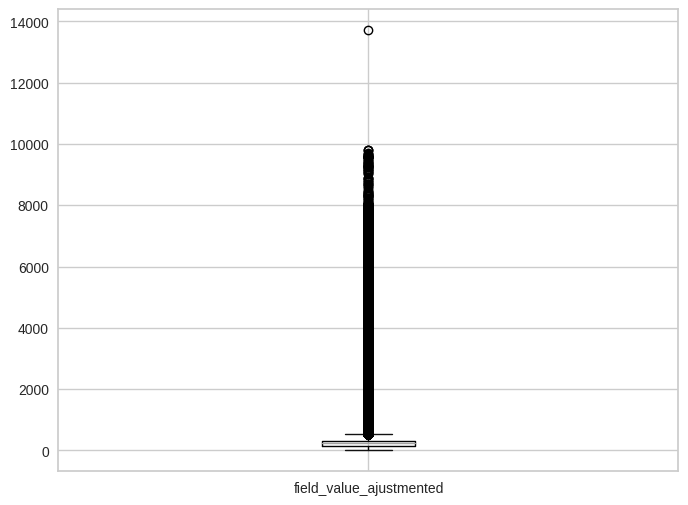

In [4]:
# Create a boxplot of the 'values' column
plt.figure(figsize=(8, 6))
df_shrink.boxplot(column='field_value_ajustmented')

# Save the plot to a file (e.g., 'boxplot.png')
plt.savefig(f'{DIRECTORY}boxplot.png')

# Show the plot
plt.show()

In [5]:
# Calculate the number of outliers using the interquartile range (IQR) method
Q1 = df['field_value_ajustmented'].quantile(0.25)
Q3 = df['field_value_ajustmented'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_shrink[(df_shrink['field_value_ajustmented'] < Q1 - 1.5 * IQR) | (df['field_value_ajustmented'] > Q3 + 1.5 * IQR)]

# Get the number of outliers
num_outliers = len(outliers)
logger.info(f"Number of outliers: {num_outliers}" )
logger.info(f"Number of dataset: {len(df_shrink)}")
fraction = num_outliers / len(df_shrink)
logger.info(f"Fraction of outliers: {fraction}")

__main__ - INFO - Number of outliers: 13522
__main__ - INFO - Number of dataset: 281261
__main__ - INFO - Fraction of outliers: 0.04807634190307224


### Train models

In [28]:

# Setup the anomaly detection experiment
anomaly_setup = setup(df_shrink, max_encoding_ohe=500,pca=True,session_id=123, n_jobs = -1,
                      numeric_features= ['field_value_ajustmented', 'mean_value'],
                      categorical_features=['sgPartido', 'txtFornecedor'],
                      ignore_features=ignored_features, date_features=['datEmissao'])


for i in tqdm(MODELS):
    try:
        model = create_model(i, fraction=fraction)

        # Check if directory exists, if not create it
        if not os.path.exists(f'{DIRECTORY}{model.__class__.__name__.upper()}'):
            os.makedirs(f'{DIRECTORY}{model.__class__.__name__.upper()}')

        # Save the model
        save_model(model, f'{DIRECTORY}{(model.__class__.__name__.upper())}/model')
    except Exception as e:
        print(e)
        print(f'Model {i} not available')


,Description,Value
0,Session id,123
1,Original data shape,"(281261, 7)"
2,Transformed data shape,"(281261, 45)"
3,Ignore features,2
4,Numeric features,2
5,Date features,1
6,Categorical features,2
7,Rows with missing values,0.2%
8,Preprocess,True
9,Imputation type,simple


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:05<00:00,  5.92s/it]

_CURRENT_EXPERIMENT global variable is not set. Please run setup() first.
Model iforest not available


In [24]:
logger.info(model)

__main__ - INFO - IForest(behaviour='new', bootstrap=False, contamination=0.04807634190307224,
    max_features=1.0, max_samples='auto', n_estimators=100, n_jobs=-1,
    random_state=123, verbose=0)


In [12]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.4.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: /opt/conda/lib/python3.10/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: category-encoders, dtreeviz, explainerdashboard, fairlearn, imbalanced-learn, interpret-core, pmdarima, pycaret, pynndescent, pyod, scikit-plot, shap, sktime, tbats, umap-learn, yellowbrick


## Plot and Assign model

In [ ]:
anomaly_setup = setup(df_shrink, max_encoding_ohe=500,pca=True,session_id=123, n_jobs = -1,
                      numeric_features= ['field_value_ajustmented', 'mean_value'],
                      categorical_features=['sgPartido', 'txtFornecedor'],
                      ignore_features=ignored_features,
                      date_features=['datEmissao'])
model_anomalies = assign_model(model, score=True)

In [ ]:
logger.info(evaluate_model(model))

In [ ]:
# Concatenate the ignored features with the transformed DataFrame
final_df = pd.concat([df_shrink[ignored_features], model_anomalies], axis=1)
final_df.to_csv(f'{DIRECTORY}{model.__class__.__name__.upper()}/model_anomalies.csv')

In [ ]:
for i in tqdm(MODELS):

    model_pred = model_anomalies

    # Calculate ROC AUC score
    predict_labels = [1 if score == 1 else 0 for score in model_pred['Anomaly'].values]

    # Calculate Silhouette Coefficient
    silhouette_coeff = silhouette_score(df[['field_value_ajustmented']], predict_labels)

    # Print the Silhouette Coefficient score
    logger.info(f"Silhouette Coefficient for {i} (2 clusters): {silhouette_coeff}")

    plot_types = ['tsne','umap']
    for plot_type in plot_types:
        try:
            plot_model(model, plot = plot_type)
        except Exception as e:
            print(e)

    model_pred = model_pred.reset_index()
    #model_pred = model_pred[model_pred.field_value_ajustmented > 40]

    # save experiment
    save_experiment(f'{DIRECTORY}my_experiment')
    #!mv /content/*.png {DIRECTORY}IFOREST/
    # Plot the anomaly scores using Plotly
    fig = px.scatter(model_pred, x=model_pred['Anomaly_Score'].index, y='field_value_ajustmented', color='Anomaly',
                  color_continuous_scale='sunsetdark', title=f'{i} Anomaly Detection',
                  labels={'index': 'Index', 'field_value_ajustmented': 'field_value_ajustmented',
                          'anomaly_score': 'Anomaly Score'})
    fig.update_coloraxes(colorbar_title='Anomaly Score')
    # Update figure layout
    fig.update_layout(
      width=800,
      height=600,
      font=dict(
          family="Arial",
          size=12,
          color="black"
      ),
      title_font_size=20,
      title_font_family="Arial",
      title_font_color="black",
      coloraxis_colorbar_title="Anomaly Score",
      coloraxis_colorbar_title_font_size=14
    )
    fig.write_image(f"{DIRECTORY}{i.upper()}/scatter_plot.png")
    fig.show()


In [ ]:
!mv /content/*.txt {DIRECTORY}/MAD/

# Download Results

In [ ]:
!zip -r dataset.zip models/